In [1]:
import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install imbalanced-learn
!{sys.executable} -m pip install seaborn



---
# Task 1: Task Ordering
---

In this notebook, the tasks have been organised in the following structure:

2. **Identify Prediction Target** : conceptual decision requiring no data, establishes what we are predicting  
3. **Data Loading and Exploration** : observational only, no statistics stored or reused  
4. **Data Splitting** : must precede all operations that learn from data  
5. **Managing Missing Values** : imputation fitted on train only  
6. **Encoding Categorical Variables** : encoders fitted on train only, applied via transform to val/test  
7. **Feature Scaling** : fitted on train only; must precede SMOTE  
8. **Feature Selection** : computed on train only; must precede scaling  
9. **Addressing Class Imbalance (SMOTE)** : applied to train only, after scaling  
10. **Training Logistic Regression** : model fitted on processed train, evaluated on validation set  

These tasks have been ordered in this way to ensure the following principles:

---

### 1. Identify Prediction Target

- **Allowed information**: understanding of concept and objective of model  
- **Must not use**: feature and target statistics computed from the full dataset  
- **risk if misordered**: Cannot train a model without understanding what we want it to do. We couldn't select the features to determine a target we don't know.

This step is conceptual and does not involve learning from the data.

---

### 2. Data Loading and Exploration

- **Allowed information**: observational inspection of distributions and dataset structure  
- **Must not use**: statistics that will later be reused for scaling, encoding or imputation  
- **Leakage risk if misordered**: storing the full dataset statistics for later preprocessing would introduce data leakage. In this case we are only exploring, we need to understand characteristics of each column to be able to understand what we should be careful with during feature selection and handling class imbalance.

Exploration must remain descriptive only.

---

### 3. Data Splitting

- **Allowed information**: full dataset used to create stratified train, validation and test splits  
- **Must not use**: fitting any transformation before splitting  
- **risk if misordered**: fitting transformations before splitting causes the model to indirectly learn from validation and test distributions. We can only learn from the training set and therefore alterations should only be done to this section of data.

Splitting must occur before any operation that estimates parameters from the data.

---

### 4. Managing Missing Values

- **Allowed information**: imputation statistics computed from the training set only  
- **Must not use**: imputation statistics derived from the validation or test data  
- **Leakage risk if misordered**: using the full dataset statistics leaks distributional information into training.

Imputation must be fitted on the training set and applied via transform to validation and test sets.

---

### 5. Encoding Categorical Variables

- **Allowed information**: category mappings learned from the training set  
- **Must not use**: category frequencies or mappings derived from full dataset  
- **Leakage risk if misordered**: encoding based on full dataset allows the model to incorporate validation or test distributional information  

Encoders must be fitted on training data only.

---

### 6. Feature Scaling

- **Allowed information**: mean and standard deviation computed from training data only  
- **Must not use**: scaling parameters fitted on the full dataset  
- **Leakage risk if misordered**: scaling before splitting causes validation and test statistics to influence training. Scaling before feature selection would destroy the variance information needed by the threshold filter

Scaling must follow feature selection and must precede SMOTE, since SMOTE relies on distance computations in feature space.

---

### 7. Feature Selection

- **Allowed information**: variance and correlation statistics computed from the training set only  
- **Must not use**: feature selection performed using the full dataset or held-out sets  
- **Leakage risk if misordered**: selecting features using validation or test information allows indirect learning from held-out data. Additionally, applying StandardScaler before this step would force all feature variances to exactly 1, making the variance threshold meaningless — no features would ever be dropped

Feature selection must precede scaling and must be fitted exclusively on the training set.

---



### 8. Addressing Class Imbalance (SMOTE)

- **Allowed information**: training data only, after scaling  
- **Must not use**: validation and test sets  
- **Leakage risk if misordered**: SMOTE applied before splitting would generate synthetic samples influenced by validation and test data, contaminating evaluation. SMOTE applied before scaling would generate geometrically distorted synthetic points due to unequal feature magnitudes

SMOTE is applied after scaling to ensure correct geometry in feature space.

---

### 9. Training Logistic Regression

- **Allowed information**: fully processed and resampled training set  
- **Must not use**: validation or test observations during fitting  
- **Leakage risk if misordered**: tuning or training on validation or test data leads to optimistic bias  

The model is fitted only on the processed training data and evaluated on untouched validation data.

---

## Example of Incorrect Ordering and Its Consequences

If StandardScaler were fitted on the full dataset before splitting, the scaler would calculate the mean and standard deviation using not only the training data but also the validation and test observations. The training set would therefore be scaled using statistics partially derived from held-out data, meaning the model would implicitly benefit from knowledge of the unseen distribution. This would result in validation metrics that are optimistically biased and would not generalise properly to truly unseen data.

---
## Task 2: Identify the Prediction Target
---

Given the dataset, it can be determined that the `y` column is the appropriate target variable, since it directly answers the question: "has the client subscribed to the term deposit?". This column encodes the outcome of interest, namely whether the client subscribed to a term deposit (yes or no), and represents the objective the bank seeks to predict before making contact decisions. 

The variable is binary, meaning there are only two possible outcomes. This makes it suitable for logistic regression and clearly defines the problem as a **binary classification task**. The goal is to predict, given the client and campaign information available at the time of contact, whether a client will subscribe to a term deposit.

---

### Variables That Should Not Be Used as Targets

#### `poutcome`

The variable `poutcome` specifies the outcome of the previous marketing campaign. At first glance, it may appear to answer a similar question regarding subscription success. However, it refers to a past campaign and is already known at the time of the current decision. It therefore serves as a predictor rather than the outcome we aim to forecast. Treating it as the target would shift the modelling objective away from the current campaign.

#### `duration`

Call duration in seconds might appear to be a useful target or proxy for success, since longer calls often correlate strongly with subscription. However, `duration` is only known after the call ends, at which point the outcome is already determined. Using it as a target or predictor would introduce temporal leakage, as the model would rely on information unavailable at prediction time. For this reason, it must be excluded from the feature set entirely.

---
## Task 3: Data Loading and Exploration
---
Data loading and exploration is performed **before any operation that learns from data** and **before splitting**. This allows us to understand the full dataset structure, identify potential issues and make informed decisions about preprocessing. At this point, exploration carries no leakage risk since no statistics are being stored or reused. This stage is purely observational.

In [2]:
import pandas as pd

In [3]:
#printing out the first 15 elements
df = pd.read_csv('bank-additional.csv', sep=';')
print(df.head(15))

    age            job   marital            education  default  housing  \
0    30    blue-collar   married             basic.9y       no      yes   
1    39       services    single          high.school       no       no   
2    25       services   married          high.school       no      yes   
3    38       services   married             basic.9y       no  unknown   
4    47         admin.   married    university.degree       no      yes   
5    32       services    single    university.degree       no       no   
6    32         admin.    single    university.degree       no      yes   
7    41   entrepreneur   married    university.degree  unknown      yes   
8    31       services  divorced  professional.course       no       no   
9    35    blue-collar   married             basic.9y  unknown       no   
10   25       services    single             basic.6y  unknown      yes   
11   36  self-employed    single             basic.4y       no       no   
12   36         admin.   

In [4]:
#maybe splitting the dataset is better to do before.

print("Shape:", df.shape)
print("\nData types:", df.dtypes)
print("\nSummary Statistics:", df.describe())



Shape: (4119, 21)

Data types: age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Summary Statistics:                age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.000000     0.000000   
25%      32.000000

the shape tells us there are 4119 rows and 21 columns (20 features and 1 target).

In [5]:
numerical = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(include='object').columns.tolist()

print("Numerical variables:", numerical)
print("\nCategorical variables:", categorical)

Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical variables: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


y
no     3668
yes     451
Name: count, dtype: int64

Class balance (%):
 y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64


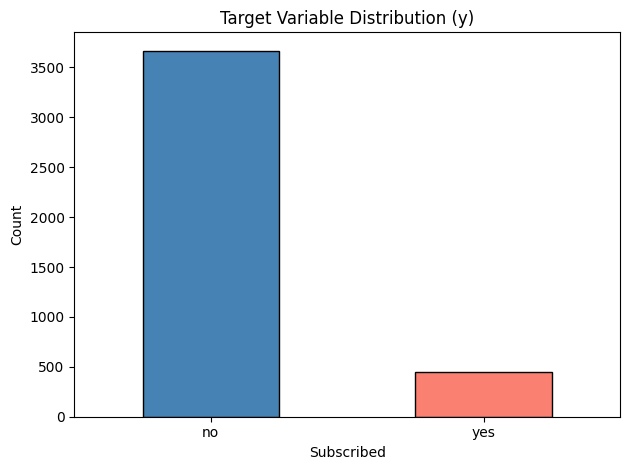

In [6]:
#Now we are going to loot at the target variable distribution to look at class imbalance.
import matplotlib.pyplot as plt

counts = df['y'].value_counts()
print(counts)
print("\nClass balance (%):\n", df['y'].value_counts(normalize=True) * 100)

counts.plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Target Variable Distribution (y)')
plt.xlabel('Subscribed')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The target variable `y` is heavily imbalanced. This will influence the pipeline directly. Takes these into account when separating the dataset: stratified splitting must be used to ensure that each split preserves this proportion. In addition, a model trained on this distribution might result in defaulting to the Zero Rule baseline, where the model will always predict no achieving a high accuracy with zero predictive value. This imbalance may cause the model to favour the majority class, leading to high accuracy but poor minority recall. Stratified splitting and imbalance handling will therefore be required.

Now we also want to understand which variables are missing:

In [7]:
print("Explicit nulls:\n", df.isnull().sum())

# Implicit missing values encoded as 'unknown'
print("\nImplicit missing values ('unknown'):")
for col in categorical:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")

Explicit nulls:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Implicit missing values ('unknown'):
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)


Here we see that there are no explicit missing values but there are implicit.
Implicit missing variables might be an issue for education, housing, loan (<5%) and especially default.

The value of "unknowns" for default is too high so we cannot drop the variables, better to use it as a different category.

In this case, no records will be dropped off from the dataset since the value of the missing is too small to be significant.

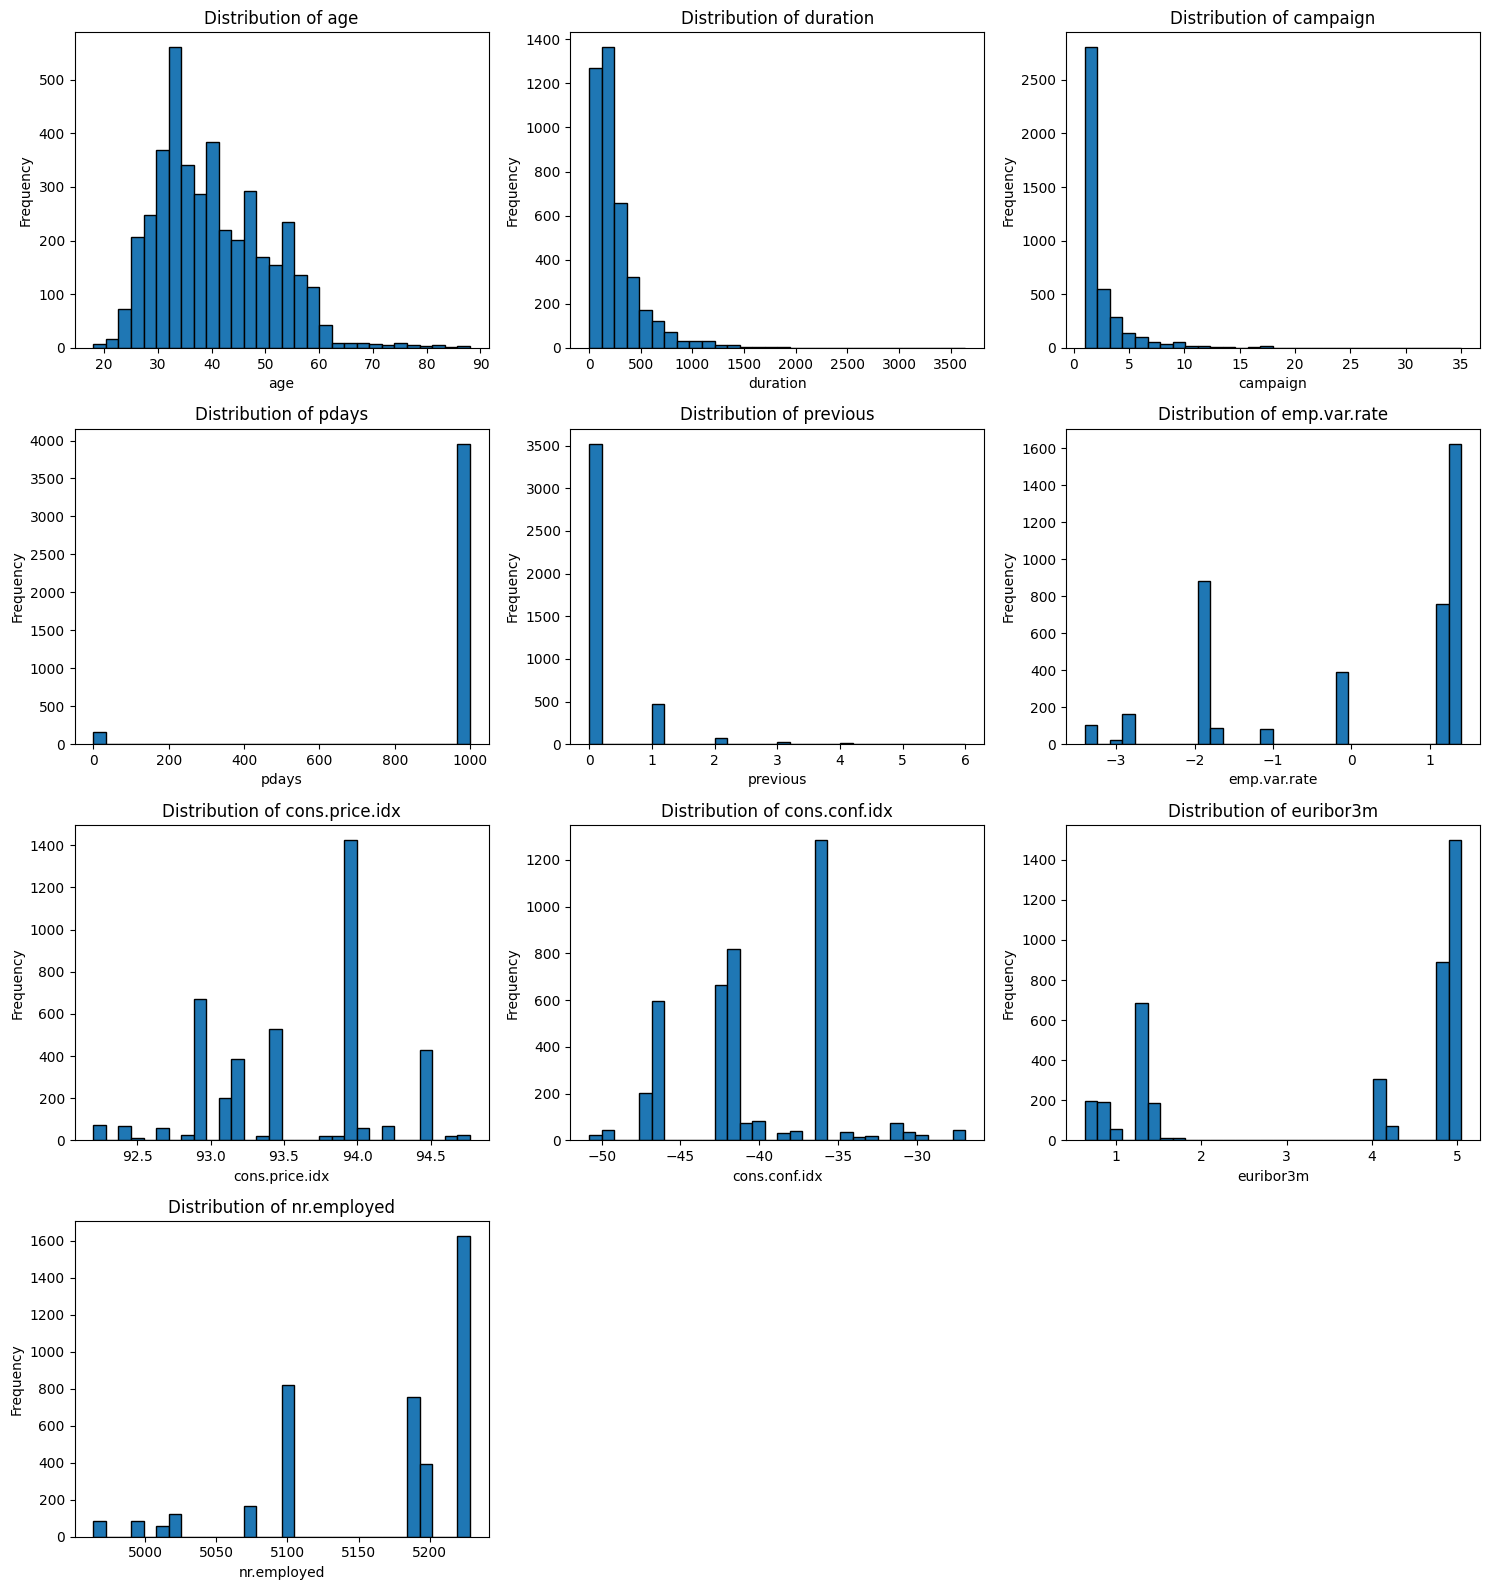

In [8]:
import math
# here we investigate two of the numerical values age and duration
#Numerical variables: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

numerical_vars= ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

n_variables= len(numerical_vars)

cols=3
rows= math.ceil(n_variables/cols)


fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(numerical_vars):
    df[col].plot(
        kind='hist',
        bins=30,
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

It is important that we consider the skewness of duration, campaign previous and pdays. This might affect the results. Strong right skew suggests the presence of outliers which may disproportionately influence models sensitive to scale, such as logistic regression. Scaling or transformation may therefore be required.

Now the same for categorical values:

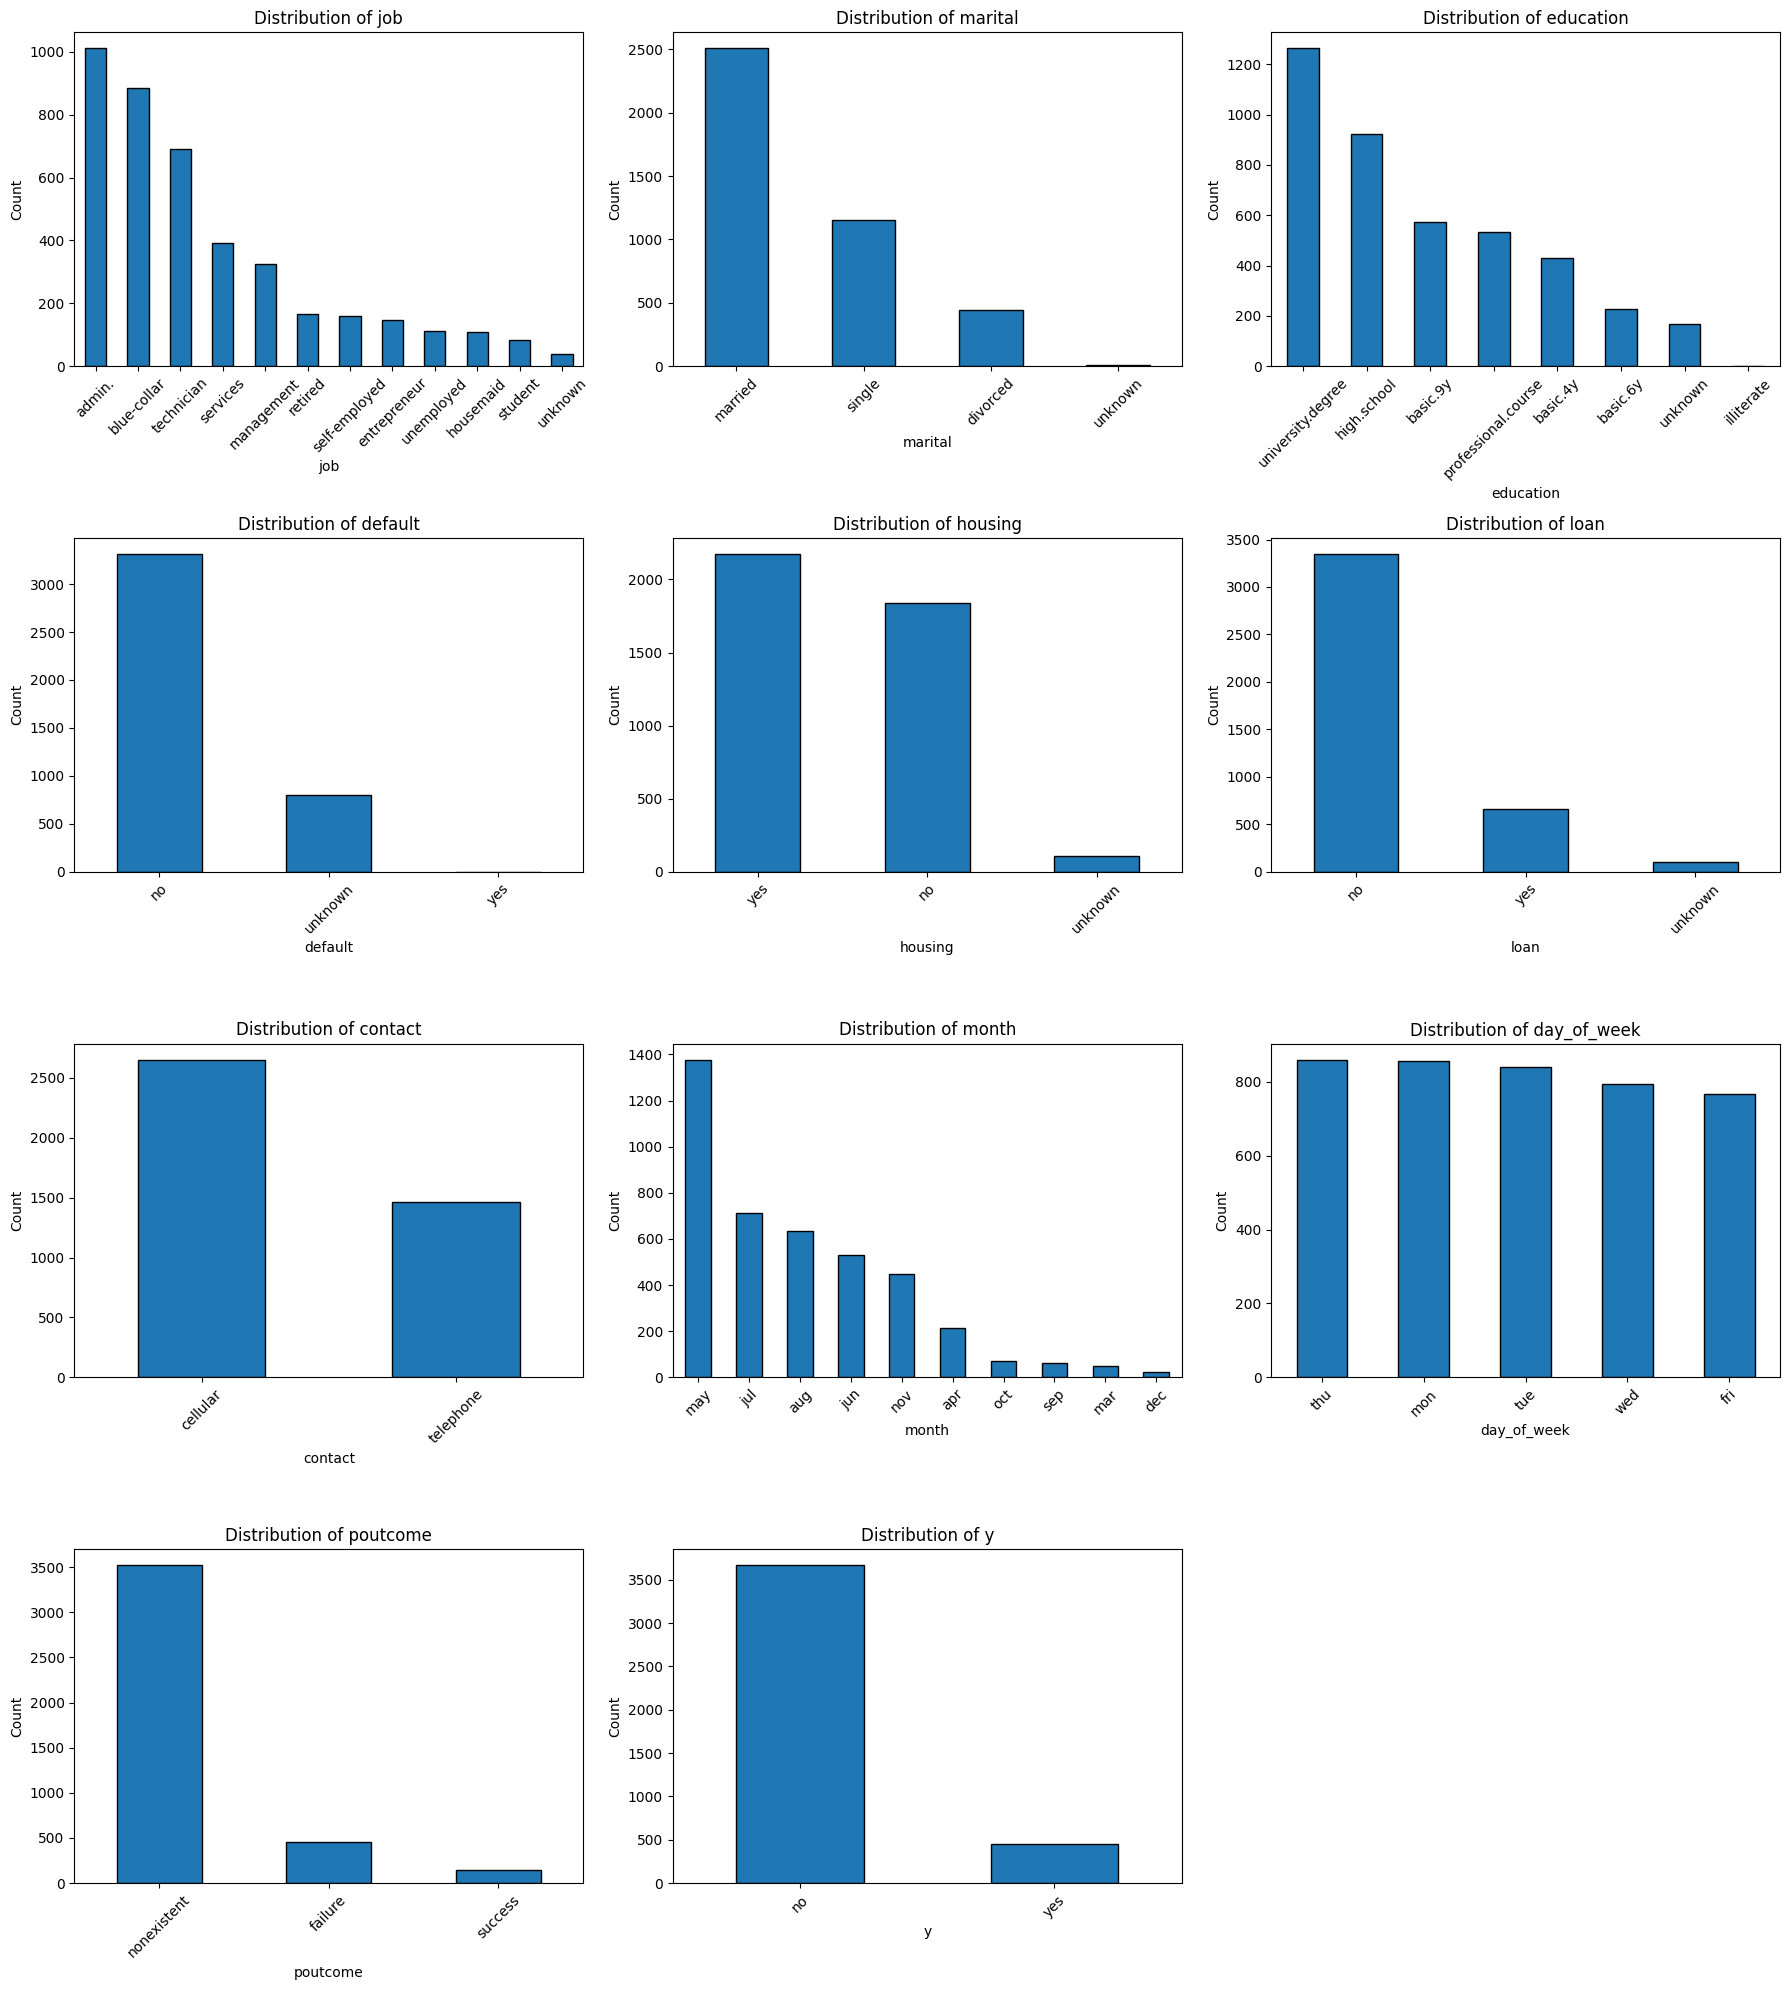

In [9]:
import matplotlib.pyplot as plt
import math

categorical_vars = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week',
    'poutcome', 'y'
]

n = len(categorical_vars)

cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i],
        edgecolor='black'
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

From these graphs we can see there is a great class imbalance, for default, most of the values are "no". Highly dominant categories may limit the discriminatory power of these variables and should be assessed during feature selection.

Other categories that also have imbalance are:
- marital status
- job
- education
- month
- poutcome
- y

Furthermore, the summary statistics reveal signs of **right skew** in several variables: `age`, `campaign`, `pdays`, and `previous` all show means exceeding their medians. Notably, `pdays` is dominated by the value 999, which is a sentinel value encoding "client was not previously contacted" rather than a genuine numeric measurement. In other words this variable is not purely numerical but partially categorical in nature. The sentinel value 999 encodes a structural condition rather than elapsed time. It must therefore be recoded to avoid misleading the model.

As aforementioned, the variable that requires special attention is `duration`. This is because it is highly right skewed and contains extreme values. Moreover, `duration` is temporal leakage. Call duration is only known *after* the conversation ends (at which point the outcome is already determined). A model trained with `duration` as a feature would be learning from information that is unavailable at prediction time. This variable should be discarded for any realistic predictive model.

Because of this analysis the only column that will be dropped at this stage will be duration. This step might also be done during feature selection, but it seems to be obvious this field shouldn't be used therefore it was dropped at this stage, so we dont accidentaly include it in any other stage of the production pipeline.

In [10]:
df = df.drop(columns=['duration'])
X = df.drop('y', axis=1)
y = df['y']

Overall, this exploratory analysis reveals three modelling considerations: class imbalance in the target, sentinel encoding in pdays and temporal leakage in duration. These observations directly inform subsequent preprocessing decisions.

---
## Step 4: Data Splitting.
---

This has to be done before any operation that learns from data.
It is also always done before steps that compute distributional statistics, e.g., feature scaling, imputation, encoding,
feature selection, dimensionality reduction, model training (SESSION 8)

In this case, stratification is important since many of the classes seem to be unbalanced. Therefore, we will use stratified splitting on 'y' preserving class proportions in the split sets.

In [11]:
import sys
!{sys.executable} -m pip install scikit-learn

In [12]:
from sklearn.model_selection import train_test_split

#Here we are doing the first split. for obtaining the training and test 60% and 40%
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

#now for the test we split in 50% for the validation set. Meaning the data is split into 60% (training) 20%(testing) and 20% (validation).

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,  # 50% of 40% = 20%
    stratify=y_temp,
    random_state=42
)

print(f"Train:      {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test:       {X_test.shape[0]} rows")

Train:      2471 rows
Validation: 824 rows
Test:       824 rows


### Explanation for this step:
Here I have split the data into 60% for training, 20% for testing and the other 20% for validation. This was implemented using a two step stratified split: first, the dataset was split into training(60%) and a temporary set(40%)and then the temporary set was split equally into validation (20%) and test(20%) sets.

The training set has the largest proportion of data so the model parameters are learned exclusively from this data. In other words, a larger training set allows for an improved parameter stability and reduces variance. The validation and test sets must be large enough to reliably estimate performance and support model adjustments. Overall, this split has been selected to optimise learning capacity whilst maintaining enough data to make sure the model is reliable.

Furthermore, stratified splitting was performed with respect to the target variable to endure that the proportion of each class (if they subscribed or didn't) is preserved across training, validation and test sets. This is essential because there is quite an imbalance in the target variables that could lead the subset to be disproportionate which would then influence the accuracy, precision and recall making them unreliable.

The data has been split before any preprocessing steps (any operations that learn from the data) to prevent from data leakage:
* `Preprocessing leakage`: any step that computes statistics from the data, such as means and variances for scaling or global statistics for imputation, must be fitted exclusively on the training set. If these steps were applied to the full dataset before splitting, the model would indirectly see the distribution of the validation and test sets during training, producing over-optimistic performance estimates that do not reflect true generalisation.
* `Group leakage`: if samples sharing a common entity or group were split randomly across training and test sets, those sets would no longer be statistically independent. This might not be the specific case in for this database, but care should still be taken.

---
# STEP 5: MANAGING MISSING VALUES
---


Missing value analysos os conducted on the **training set only**, this is consistent with the pipeline discipline studied in class. Applying imputation statistics from the full dataset would constitute data leakage.

Now we focus on the categorical columns.

In [13]:
#Some was done before but we will repeat and delve into it more in this segment
#checking for explicit variables
# Explicit missing values (NaN) — TRAIN ONLY
missing_count = X_train.isna().sum()
missing_pct = (X_train.isna().mean() * 100).round(2)

print("Explicit missing values (count) — X_train:")
print(missing_count[missing_count > 0])

print("\nExplicit missing values (%) — X_train:")
print(missing_pct[missing_pct > 0])

Explicit missing values (count) — X_train:
Series([], dtype: int64)

Explicit missing values (%) — X_train:
Series([], dtype: float64)


In [14]:
#Now looking at the implicit variables
cat_cols = X_train.select_dtypes(include="object").columns

unknown_count = (X_train[cat_cols] == "unknown").sum().sort_values(ascending=False)
unknown_pct = ((X_train[cat_cols] == "unknown").mean() * 100).round(2)

report = unknown_count.to_frame("unknown_count").join(unknown_pct.to_frame("unknown_%"))
print("\nImplicit missingness encoded as 'unknown' — X_train:")
print(report[report["unknown_count"] > 0])


Implicit missingness encoded as 'unknown' — X_train:
           unknown_count  unknown_%
default              492      19.91
education            104       4.21
housing               55       2.23
loan                  55       2.23
job                   20       0.81
marital                7       0.28


### Explicit Missing Values
No explicit NaN values were detected in any column. All missingness in this dataset is implicit.

### Implicit Missing Values: "unknown" Category

The fact that the database contains `unknown` information could be due to the client not sharing this information and therefore might be informative for the prediction, therefore these "unknown" variables can be kept as a category. The extent of implicit missingness in the training set is as follows:

| Variable | Unknown Count | Unknown % |
|---|---|---|
| `default` | ~492 | ~19.9% |
| `education` | ~104 | ~4.2% |
| `housing` | ~55 | ~2.2% |
| `loan` | ~55 | ~2.2% |
| `job` | ~20 | ~0.8% |
| `marital` | ~7 | ~0.3% |

**Here, we retain "unkown" as an explicit category.** The fact that a client did not disclose information may itself be informative. For example, clients who decline to state their credit default status may systematically differ from those who disclose it. This is a **modelling decision** rather than a data cleaning decision: we are preserving missingness as signal rather than treating it as noise to be corrected.

Furthermore, dropping these rows would cause significant data loss (`default` is at 20%) and would also introduce selection bias.

I have decided to not use any form of statistical imputation to prevent data leakage. This is done so no parameters that aren't actually represented in the database are learnt in this step.

Now we have to analyse the numerical predictors.

In [15]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

print("Numerical columns:")
print(num_cols)

print("\nExplicit missing in numerical columns (TRAIN ONLY):")
print(X_train[num_cols].isna().sum())

Numerical columns:
Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

Explicit missing in numerical columns (TRAIN ONLY):
age               0
campaign          0
pdays             0
previous          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64


In [16]:
import numpy as np

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    print(f"Column: {col}")

    series = X_train[col]

    print(f"Min: {series.min()}")
    print(f"Max: {series.max()}")
    print(f"Mean: {series.mean():.2f}")
    print(f"Std: {series.std():.2f}")
    print(f"1st percentile: {np.percentile(series, 1)}")
    print(f"99th percentile: {np.percentile(series, 99)}")

    # Check for common sentinel values
    suspicious_values = [-1, 0, 999, 9999]
    for val in suspicious_values:
        if val in series.values:
            count = (series == val).sum()
            print(f"Value {val} appears {count} times ({count/len(series)*100:.2f}%)")

    # Show top 5 largest values
    print("Top 5 largest values:")
    print(series.sort_values(ascending=False).head())

    # Show bottom 5 smallest values
    print("Bottom 5 smallest values:")
    print(series.sort_values().head())

Column: age
Min: 18
Max: 86
Mean: 40.12
Std: 10.32
1st percentile: 24.0
99th percentile: 68.30000000000018
Top 5 largest values:
696     86
1123    85
150     82
3549    82
338     81
Name: age, dtype: int64
Bottom 5 smallest values:
477     18
899     18
1377    20
200     21
1510    21
Name: age, dtype: int64
Column: campaign
Min: 1
Max: 35
Mean: 2.57
Std: 2.68
1st percentile: 1.0
99th percentile: 14.0
Top 5 largest values:
2552    35
3564    29
3241    29
56      27
2988    23
Name: campaign, dtype: int64
Bottom 5 smallest values:
3951    1
1354    1
2196    1
3740    1
3177    1
Name: campaign, dtype: int64
Column: pdays
Min: 0
Max: 999
Mean: 957.60
Std: 198.55
1st percentile: 3.0
99th percentile: 999.0
Value 0 appears 2 times (0.08%)
Value 999 appears 2368 times (95.83%)
Top 5 largest values:
1802    999
4059    999
2020    999
2573    999
2631    999
Name: pdays, dtype: int64
Bottom 5 smallest values:
3127    0
1046    0
1022    1
3665    1
405     2
Name: pdays, dtype: int64
Col

### Sentinel Value

Pdays goes from 0 to 999. In this case 999 is understood as "the client not being previously contacted", the rest can be understood as the amount of days since last contact. To work with this value, we will treat it as a different category and not an actual value.

The following actions will be performed:

1. A binary indicator `pdays_never_contacted` will be created to capture whether each client had ever been previously contacted.
2. The sentinel value 999 will then be replaced with 0 for those clients.

In [17]:
# Step 1: Create binary indicator FIRST
X_train["pdays_never_contacted"] = (X_train["pdays"] == 999).astype(int)
X_val["pdays_never_contacted"]   = (X_val["pdays"] == 999).astype(int)
X_test["pdays_never_contacted"]  = (X_test["pdays"] == 999).astype(int)

# Step 2: Replace sentinel with 0
X_train.loc[X_train["pdays"] == 999, "pdays"] = 0
X_val.loc[X_val["pdays"] == 999, "pdays"]     = 0
X_test.loc[X_test["pdays"] == 999, "pdays"]   = 0

print("pdays_never_contacted distribution in train:")
print(X_train["pdays_never_contacted"].value_counts())

pdays_never_contacted distribution in train:
pdays_never_contacted
1    2368
0     103
Name: count, dtype: int64


For the numerical variables, no explicit NaN values were detected. However, the variable pdays contains the value 999 in 95.83% of training examples. In this dataset, 999 encodes “client was not previously contacted” and does not represent a genuine numeric measurement.

This is not true missingness, but structural encoding. Therefore:
- A binary indicator variable (never_contacted) was created to capture this condition.
- The numeric interpretation of pdays is preserved for clients who were previously contacted.

All other numerical variables exhibit realistic ranges and do not contain sentinel values such as -1 or 999. Therefore, no further intervention was required.



In this case, no statistical imputation (mean, median or mode) was performed. Nevertheless if we were to include it, the statistics would be performed solely in the training dataset to avoid data leakage. If it had been done, it should only be applied to the training set to avoid data leakage.

Finally, no rows were dropped. Although missingness was negligible for some variables (e.g., marital and job), it was moderate for other, particularly default (20%). Dropping these rows would have caused significant data loss and potential bias, so "unkown" was retained as an explicit category. For pdays, the value 999 is not true missingness but a sentinel indicating the client was never previously contacted; this was managed by engineering a binary flag (pdays_never_contacted) and setting the numerical value to 0.


One final detail worth mentioning is the difference between the cleaning of the data and the modelling decisions that were taken here. Correcting a genuine data entry error would constitute a data cleaning decision, as it restores the intended value. By contrast, retaining "unkown" as an explicit category is a **modelling decision**: we are not correcting the data, but rather choosing ti treat missingness as a potentially informative signal. Something similar was done to `pdays_never_contacted`. With it the structural patern of the data was encoded instead of fixing it as an error.

---
### Task 6: Encoding Categorical Variables
---


For this step is classifying each variable by type, different types will be encoded differently.


**Nominal Variables**: job, marital, contact, month, day_of_week, poutcome. These have no meaningful order therefore one-hot-encoding is used, creating a binary column for each category. I was wondering whether to use cyclical encoding for day_of_week or month but after careful research (before in the visualising statistics section the graph showed a high right skewness and not a more sinusoidal pattern) I realised that it was not meaningful in this case since there is no reason to assume that december behaviour smoothly transitions to that of january or sunday to monday; therefor these columns were assessed as nominal.

**Ordinal Variables** education. The education has an order. 

**Binary Variables** default, housing and loan. These take the three variables yes, no and unkown (1,0,-1). 

**Numerical Variables**age, campaign, pdays, previous, emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed. These are already numeric so no encoding is necessary. They will be taken into account in the standardisation and scaling steps.


### Fit on Training Data Only
One of the main points to extract from this snippet of code is that "fit" is ony performed on the training set; The validation and test set are "transformed". On the one hand "fit" is what allows the encoder to learn from stored values to the validation and test sets.

### Effect on Dimensionality
One-hot-encoding substantially expands the feature space, `job` alone has 11 categories, producing 10 new columns.

### Interpretability of model coefficients

The use of one-hot-encoding produces binary indicator columns, meaning each logistic regression coefficient represents the log-odds change of subscribing when that categor is present relative to the dropped reference category. This makes coefficients directly interpretable.

### Decision boundaries of a linear model

Logistic regression learns a single linear decision boundary in feature space. By encoding categorical variables numerically, we allow the model to incorporate them into this linear boundary. One-hot encoding, as aforementioned, assigns each category its own coefficient, meaning the model can adjust the linear predictor separately for each category. This enables the model to treat each category independently within the linear structure. Without encoding, logistic regression would not be able to incorporate categorical variables at all.

However, the boundary remains globally linear: the model cannot learn that, for example, the effect of month interacts with job unless interaction terms are explicitly engineered.

In [18]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd

#first we encode the target
y_train = (y_train == 'yes').astype(int)
y_val   = (y_val == 'yes').astype(int)
y_test  = (y_test == 'yes').astype(int)

#now we work with the binary columns 
binary_cols = ['default', 'housing', 'loan']
binary_map = {'yes': 1, 'no': 0, 'unknown': -1}

for col in binary_cols:
    X_train[col] = X_train[col].map(binary_map)
    X_val[col]   = X_val[col].map(binary_map)
    X_test[col]  = X_test[col].map(binary_map)



# ordinal encoding is used for education
education_order = [['illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
                    'high.school', 'professional.course', 'university.degree', 'unknown']]

oe = OrdinalEncoder(categories=education_order)
X_train[['education']] = oe.fit_transform(X_train[['education']])
X_val[['education']]   = oe.transform(X_val[['education']])
X_test[['education']]  = oe.transform(X_test[['education']])

#nominal columns employ one hot encoding
nominal_cols = ['job', 'marital', 'contact', 'month', 'day_of_week', 'poutcome']
# one-hot encoding is performed on these columns since the values they contain have no meaningful order
#drop= "first" to remove one dummy per variable to avoid the dummy variable trap.
# "ignore" ensures that if val or test contains a category not seen in training, it gets all zeros instead of crashing.
# sparse_output= False returna a refular numpy array isnteado of a sparse matrix which is easier to work with.
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')

# Fit on train only.
ohe_train = ohe.fit_transform(X_train[nominal_cols])
ohe_cols  = ohe.get_feature_names_out(nominal_cols)

X_train = X_train.drop(columns=nominal_cols).reset_index(drop=True)
X_train = pd.concat([X_train, pd.DataFrame(ohe_train, columns=ohe_cols)], axis=1)

# Transform val and test
ohe_val = ohe.transform(X_val[nominal_cols])
X_val   = X_val.drop(columns=nominal_cols).reset_index(drop=True)
X_val   = pd.concat([X_val, pd.DataFrame(ohe_val, columns=ohe_cols)], axis=1)

ohe_test = ohe.transform(X_test[nominal_cols])
X_test   = X_test.drop(columns=nominal_cols).reset_index(drop=True)
X_test   = pd.concat([X_test, pd.DataFrame(ohe_test, columns=ohe_cols)], axis=1)

# numerical columns (age, campaign, pdays, previous, emp.var.rate, cons.price.idx,
# cons.conf.idx, euribor3m, nr.employed) require no encoding as they are already numeric.
# They will be standardised in the scaling step.

# Task 7 Feature Scaling

StanderdScalar has been apploed for feature scaling to perform normalisation. This turns the mean to 0 and the standard deviation to 1. This is especially useful for logistic regression since:
1. logistic regression uses gradient descent for optimisation. In gradient descent, when features opperate vastly un different scales, the loss surface becomes elongated and gradient descent converges slowly or unstably. Scaling produces more spherical loss surface which then improves optimisation stability and convergence speed as discussed in lecture 8.
2. Logistic regression applies L2 relularisation by default, which penalises large coefficients. Without scaling, features with larger raw magnitudes receive a proportionally smaller penalty, meaning regularisatioon treats features unequally nased on their original units rather than their actual importance. Scaling ensures L2 regularisation applies a fair and equal penalty across all features. 


In [19]:

from sklearn.preprocessing import StandardScaler

continuous_cols = [col for col in ['age', 'campaign', 'pdays', 'previous',
                   'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                   'euribor3m', 'nr.employed'] if col in X_train.columns]

scaler = StandardScaler()

# fit on training data only
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols]   = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols]  = scaler.transform(X_test[continuous_cols])

# verify scaling worked
print(X_train[continuous_cols].describe().round(2))

           age  campaign    pdays  previous  emp.var.rate  cons.price.idx  \
count  2471.00   2471.00  2471.00   2471.00       2471.00         2471.00   
mean     -0.00     -0.00     0.00     -0.00          0.00           -0.00   
std       1.00      1.00     1.00      1.00          1.00            1.00   
min      -2.14     -0.59    -0.17     -0.36         -2.21           -2.34   
25%      -0.79     -0.59    -0.17     -0.36         -1.19           -0.85   
50%      -0.21     -0.21    -0.17     -0.36          0.66            0.30   
75%       0.67      0.16    -0.17     -0.36          0.86            0.72   
max       4.45     12.10    13.33     10.24          0.86            2.03   

       cons.conf.idx  euribor3m  nr.employed  
count        2471.00    2471.00      2471.00  
mean            0.00      -0.00         0.00  
std             1.00       1.00         1.00  
min            -2.22      -1.70        -2.72  
25%            -0.49      -1.30        -0.89  
50%            -0.29    

Furthermore, feature scaling is essential since scaling affects the comparability and interpretability of Logistic Regression coefficients. Without scaling it is hard for coefficients to be directly compared to each other due to the differences in magnitudes. For example age (ranging 18-88) is not easily comparable to emp.var.rate (ranging from -3 to 1.5). After using StandardScaler, all features operate on the same scale, making coefficients directly comparable.


One thing I was most confused about in this step was whether do feature selection before. The book seemed to have these tasks swapped. Nevertheless, I read in different websites that it was also possible to do it this way. At the end I tried both ways and there didn't seem to be any difference, therefore I kept this order (the same features were discarded afterwards).

---
# Task 8. Feature Selection : Cutting the Long Tail and Task-Specific Feature Selection (Boruta overkill)
---
This is done after encoding and after scaling following the pipeline provided in the slides from Lectures 6 and 7. 

Furthermore, I decided to do **feature selection** before **feature scaling** because the variance threshold uses variance to decide which features to drop; if scaling was done first, StandardScaler sets the variance of every feature to 1, meaning all features would pass the threshold and the step would become meaningless.

Feature selection will be performed in three key stages: removal of leakage variables, varianve-based filtering consistent with the lecture concept of cutting the long tail, and correlation-based filtering to reduce multicollinearity.

### Why Feature Selection Must Use Training Data Only
As aforementioned, data shouldn't be leaked. We try to avoid the rest of the sets to influence the variance of the training set. All selection decisions must be computed on the training set and applied passively to validation and test.

We will use cutting the long tail to ensure that only informative features are used.

Boruta was not done in this task because it is computationally disproportionate; L1 regularisation was considered but rejected in favour of explicit selection (L2 regularisation used instead).




Duration was already dropped before so no need to drop again

# Cutting the Long Tail
Now variance is analysed. With this features that rarely appear are removed due to their small contribution. Here, a VarianceThreshold of 0.01 is applied to identify and remove these features. This is only done in the traning set.

A threshold of 0.01 was selected. For a binary column, variance equals p(1−p) where p is the proportion of 1s. A threshold of 0.01 corresponds to features where the minority value appears in fewer than approximately 1% of observations (ones that are essentially carry no predictive information).

In [20]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)

selected_cols = X_train.columns[vt.get_support()]
dropped_low_var = list(X_train.columns[~vt.get_support()])
print("Dropped low-variance features:", dropped_low_var)

X_train = pd.DataFrame(vt.transform(X_train), columns=selected_cols)
X_val   = pd.DataFrame(vt.transform(X_val),   columns=selected_cols)
X_test  = pd.DataFrame(vt.transform(X_test),  columns=selected_cols)

Dropped low-variance features: ['job_unknown', 'marital_unknown', 'month_dec']


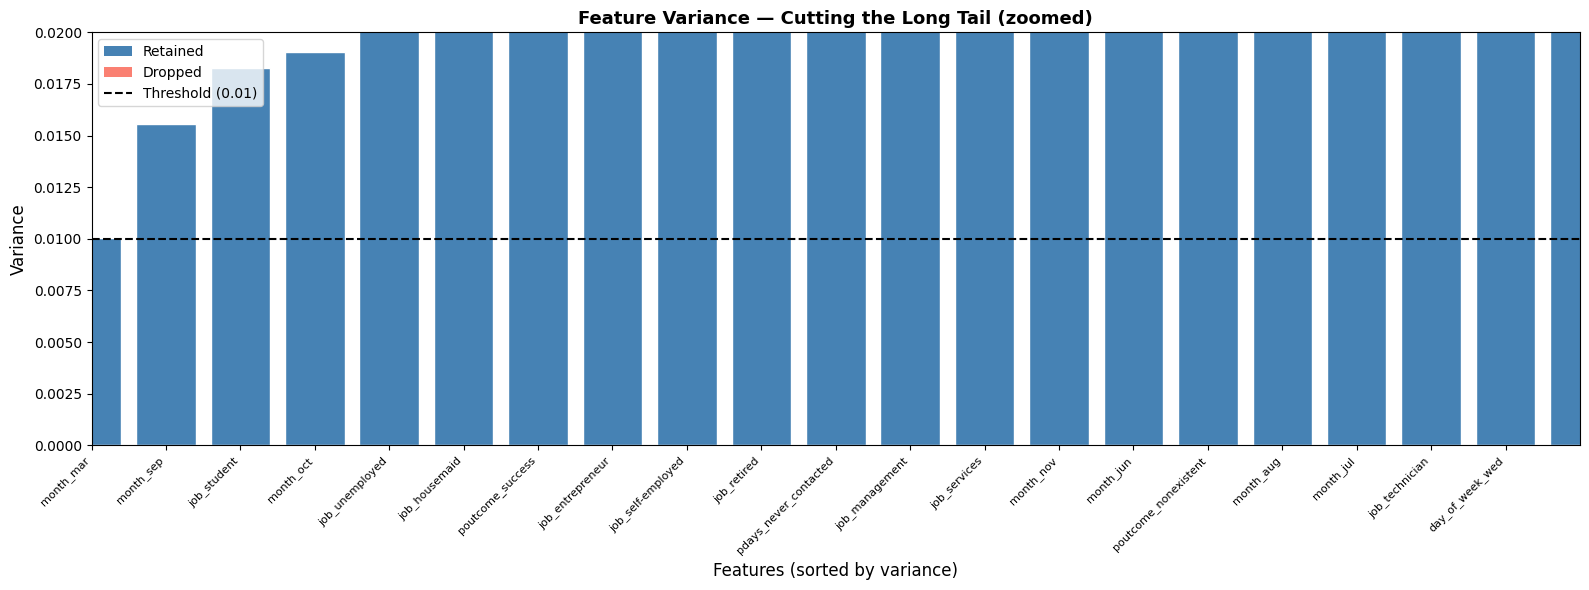

In [21]:
# Compute variances BEFORE transforming X_train
variances_series = X_train.var().sort_values()
dropped_low_var_set = set(dropped_low_var)
colors = ['salmon' if col in dropped_low_var_set else 'steelblue' for col in variances_series.index]

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(range(len(variances_series)), variances_series.values, color=colors, edgecolor='white')
ax.axhline(y=0.01, color='black', linestyle='--', linewidth=1.5)

# Show only the lowest variance features with labels
ax.set_xlim(0, 20)  # zoom into leftmost features
ax.set_ylim(0, 0.02)

ax.set_xticks(range(20))
ax.set_xticklabels(variances_series.index[:20], rotation=45, ha='right', fontsize=8)

ax.set_xlabel('Features (sorted by variance)', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('Feature Variance — Cutting the Long Tail (zoomed)', fontsize=13, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Retained'),
                   Patch(facecolor='salmon', label='Dropped'),
                   plt.Line2D([0], [0], color='black', linestyle='--', label='Threshold (0.01)')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

After running the code, job_unknown, marital_unkown and month_dec have been removed due to their rare appearance in the dataset. 

# Correlation Based Filtering

This is not specified in the slides but still fulfills the objective of removing redundant information, therefore has been included. 

Retaining highly correlated features adds no new information and can introduce multicollinearity, which would heavily destabilise coefficient estimates for Logistic Regression, making the model harder to interpret as well as making the optimisation less stable.

In this case, features with pairwise correlation above 0.85 are identified using the training set only and dropped from all three splits.

Dropped correlated features: ['euribor3m', 'nr.employed']


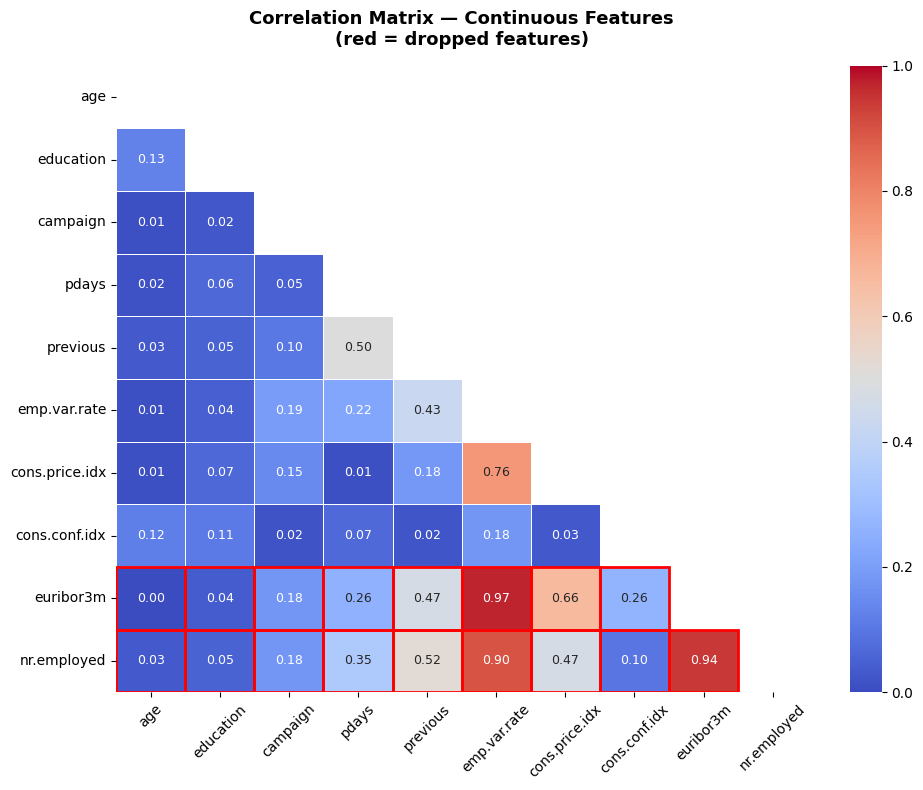

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

numerical_for_corr = X_train.select_dtypes(include=[np.number]).columns
continuous_only = [col for col in numerical_for_corr 
                   if col in ['age', 'campaign', 'pdays', 'previous',
                              'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                              'euribor3m', 'nr.employed', 'education']]

corr_matrix = X_train[continuous_only].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Dropped correlated features:", to_drop)

# --- PLOT BEFORE DROPPING ---
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=0, vmax=1,
            linewidths=0.5,
            ax=ax,
            annot_kws={'size': 9})

for i, col in enumerate(corr_matrix.columns):
    for j, row in enumerate(corr_matrix.index):
        if (col in to_drop or row in to_drop) and j > i:  # lower triangle only
            ax.add_patch(plt.Rectangle((i, j), 1, 1, fill=False,
                                        edgecolor='red', lw=2))

ax.set_title('Correlation Matrix — Continuous Features\n(red = dropped features)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# --- DROP AFTER PLOTTING ---
X_train = X_train.drop(columns=to_drop)
X_val   = X_val.drop(columns=to_drop)
X_test  = X_test.drop(columns=to_drop)

`'euribor3m'` and `'nr.employed'` are dropped due to high pairwise correlation with other features within the training set. To understand this correlation better the following code is run:

In [23]:
# Show what each dropped feature was correlated with
for col in to_drop:
    correlated_with = upper[col][upper[col] > 0.85]
    print(f"\n{col} is correlated with:")
    print(correlated_with)


euribor3m is correlated with:
emp.var.rate    0.970013
Name: euribor3m, dtype: float64

nr.employed is correlated with:
emp.var.rate    0.896018
euribor3m       0.941699
Name: nr.employed, dtype: float64


- **`euribor3m`** correlates with `emp.var.rate` at 0.97.
- **`nr.employed`** correlates with `emp.var.rate` at 0.90 and with `euribor3m` at 0.94 

`emp.var.rate` is retained as the representative macroeconomic indicator. Removing `euribor3m` and `nr.employed` reduces multicollinearity without losing information, improving coefficient stability in Logistic Regression.

### Feature Selection Before Data Splitting
Data leakage. If variance and correlation are computed on the entire dataset, information from the validation and tests sets would influence which features are retained (in other words held-out sets are no longer truly unseen). Therefore all selection decisions must be computed solely on the training set and applied passieely to the validation and test via transform.

---
# Task 9: Addressing Class Imbalance
---

Addressing Class imbalance has been done after scaling because SMOTE will be used and it is highly sensitive to the scale of the features since it does distance computations. If features are not scaled beforehand it could lead to several issues such as:
* large magnitude features dominating the distance
* synthetic samples being distorted
* geometry of the feature space is wrong

### Why SMOTE Over Other Methods

SMOTE was selected over other techniques including random oversampling, undersampling and ADASYN mainly because it was the one that most fit with the data available. **Random oversampling** was rejected since it would simply provide duplicates of the existing minority observations which could possibly lead to overfitting; undersampling was rejected since the minority class only contains 271 obsercations and reducing to this number would discard the majority of the training data; finally, ADASYN was considered because its focus on boundary regions would introduce assumptions about which minority observations matter most that are difficult to justify in this case.

# What If SMOTE Were Applied Before Splitting.
As previously mentioned; if SMOTE were applied before data splitting, synthetic points generated would be distributed accross all the dataset (training, test and validation). Meaning the test and validation sets would no longer reflect reality.


# Effect on Evaluation Metrics

It is important to take into account that accuracy becomes misleading when class imbalance is present. If a model predicts solely "no", it might achieve an accuracy over 80% but have indeed no predictive value. Moreover, we have to take into account how class imbalance affects precision and recall. in this case **Precision** would measure the proportion of clients predicted to subscribe actually did. Under class imbalance, this model will be biased towards the majority class and will rarely predict "yes", meaning that it will apear precise, but really isn't. The important statistic in this case would be **recall**, it is critical that subscribers are flagged, indeed missing a genuine subscriver (false negative) would represent lost revenue that could not be recoverd. Therefore a model that predicts more clients might be better than one that misses them. SMOTE was used here to push the decision boundary towards the minority class, thus improving recall at the cost of some precision. This tradeoff is deliverate.


In [24]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 2200, 1: 271}
After SMOTE: {0: 2200, 1: 2200}


This snippet of code shows the ratio of observations in the training dataset. Before SMOTE was applied, the ratio was approximately 88:12, meaning that there was a much higher number of negative observations compared to positive ones. This imbalance is quite significant and would likely influence the behaviour of the logistic regression model, since the algorithm would naturally focus more on minimising errors for the majority class. For this reason, SMOTE was used as an oversampling technique.

At first I considered keeping the original distribution, since I assumed that the training set should strictly represent reality. I thought that applying SMOTE and artificially balancing the classes would cause the model to fit something that was not representative of real-world proportions. However I later understood that there is a distinction between training and reality. The way we modify the training data is a tool used to shape the decision boundary and improve the model’s ability to learn minority class patterns. It does not distort how reality is evaluated, since the validation and test sets still reflect the true distribution. Therefore in the end I decided to apply SMOTE to improve the learning process while preserving realistic evaluation conditions.

After SMOTE, the ratio now becomes 1:1, having balance. Before, it was balanced towards saying no (majority class). This is because doing so would minimise the loss function without the model learning anything meaningful about whst distinguishes a subscriber. This is the Zero Rule baseling from the lecture (a model that predicts no 89% of the time achieves 89% accuracy with zero predictive power). 


The imbalance here is important since the bank's objective is to identify the minority class. Missing a genuine subscriber (false negative) is more costly to the business than incorrecly targeting a non-subscriber (false positive). A model that ignores the minority class entirely fails the task regardless of its accuracy.

---
# Task 10: Training The Model - Logistic Regression
---

Logistic Regression is the model used for this dataset since the output is binary. The following code uses 0.5 as the decision threshold.

**L2 regularisation** is used (the default for sklearn) to penalise large coefficients by adding their square magnitude to the loss function.

              precision    recall  f1-score   support

           0       0.95      0.82      0.88       734
           1       0.29      0.61      0.40        90

    accuracy                           0.80       824
   macro avg       0.62      0.72      0.64       824
weighted avg       0.87      0.80      0.83       824



/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: overflow encountered in 

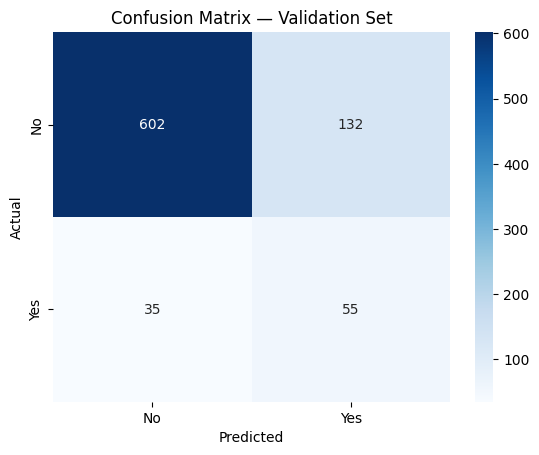

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Validation Set')
plt.show()

The default threshold 

In [26]:
y_pred_proba = model.predict_proba(X_val)[:, 1]
y_pred_adjusted = (y_pred_proba > 0.65).astype(int)
print(classification_report(y_val, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93       734
           1       0.44      0.51      0.47        90

    accuracy                           0.88       824
   macro avg       0.69      0.72      0.70       824
weighted avg       0.88      0.88      0.88       824



/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/oliviaespineiraflores/miniforge3/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## Results and Interpretation


The model was first evaluated using the default threshold of 0.5 and then using an adjusted threshold of 0.65. The results are compared below.

At a threshold of 0.5, the model achieves 80% overall accuracy, which is below the Zero Rule baseline of 89%. However, accuracy is not the most relevant metric in this case due to class imbalance. The model correctly identifies 61% of actual subscribers (Recall = 0.61), compared to 0% under the Zero Rule baseline. Precision for the positive class is 0.29, meaning that 71% of predicted subscribers are false positives. This is largely a consequence of SMOTE, which trains the model on a balanced distribution that does not reflect real-world proportions.

At a threshold of 0.65, overall accuracy improves to 88%, approaching the Zero Rule baseline, but now for the right reasons. The model becomes more conservative in predicting the positive class rather than defaulting to predicting “no”. Precision improves significantly from 0.29 to 0.44, meaning fewer false positives are generated. Recall decreases slightly from 0.61 to 0.51, indicating that the model now misses slightly more genuine subscribers. However, the F1-score improves from 0.40 to 0.47, suggesting that the balance between Precision and Recall is stronger at this threshold.

For this reason, a threshold of 0.65 was selected. In the context of bank marketing, missing a genuine subscriber (false negative) is more costly than making a wasted call (false positive), therefore maintaining strong Recall remains important. Nevertheless, the improvement in Precision from 0.29 to 0.44 is substantial enough that the slight reduction in Recall is justified by the meaningful reduction in false positives.

Overall, these results confirm that the pipeline is coherent and correctly implemented. The model meaningfully outperforms the Zero Rule baseline on the minority class while maintaining reasonable overall performance. Further improvements could involve adjusting the SMOTE sampling ratio, tuning the regularisation parameter C, or exploring class_weight='balanced' as an alternative to resampling.

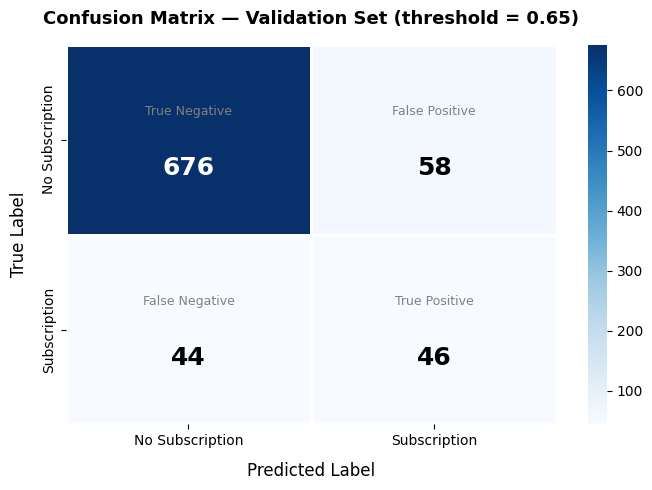

In [27]:
cm = confusion_matrix(y_val, y_pred_adjusted)

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(cm, annot=False, cmap='Blues', linewidths=2, linecolor='white',
            xticklabels=['No Subscription', 'Subscription'],
            yticklabels=['No Subscription', 'Subscription'], ax=ax)

labels = [['True Negative', 'False Positive'],
          ['False Negative', 'True Positive']]

for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.35, labels[i][j],
                ha='center', va='center', fontsize=9, color='gray')
        ax.text(j + 0.5, i + 0.65, str(cm[i][j]),
                ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm[i][j] > cm.max() / 2 else 'black')

ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('True Label', fontsize=12, labelpad=10)
ax.set_title('Confusion Matrix — Validation Set (threshold = 0.65)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

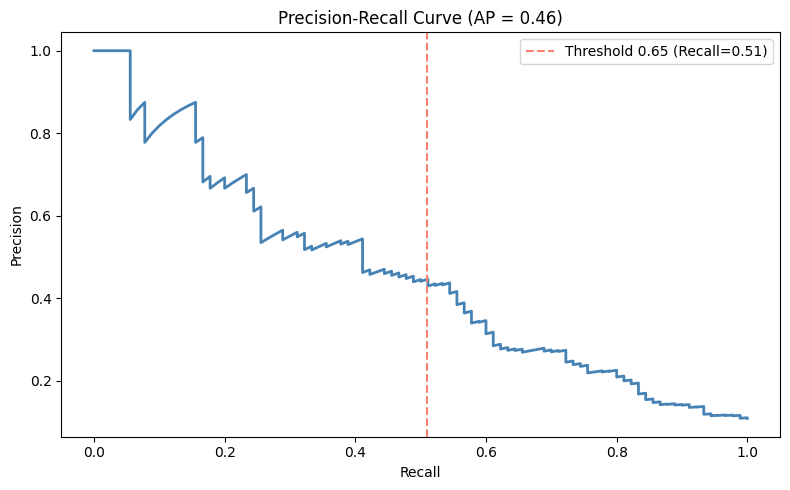

In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_curve, recall_curve, thresholds = precision_recall_curve(y_val, y_pred_proba)
ap = average_precision_score(y_val, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision_curve, color='steelblue', lw=2)
plt.axvline(x=0.51, color='salmon', linestyle='--', label='Threshold 0.65 (Recall=0.51)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AP = {ap:.2f})')
plt.legend()
plt.tight_layout()
plt.show()

This plot represents the tradeoff in this example between precision and recall.

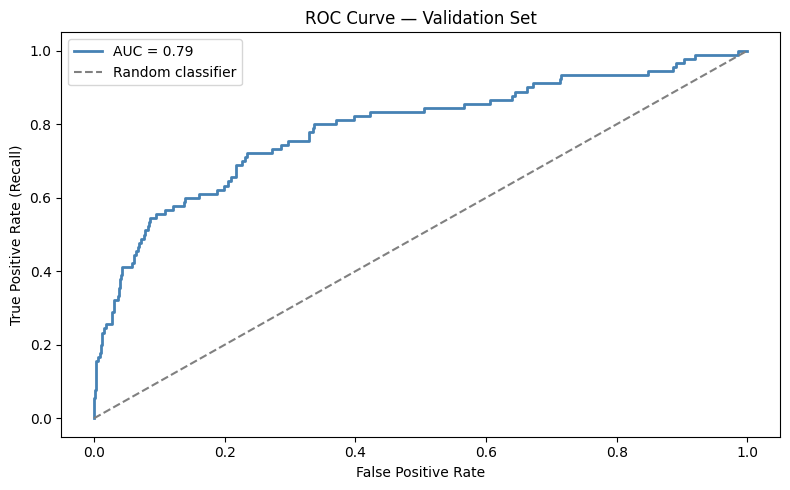

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
auc = roc_auc_score(y_val, y_pred_proba)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Validation Set')
plt.legend()
plt.tight_layout()
plt.show()

# ROC Curve Analysis

The ROC curve plots the True Positive Rate (Recall) against the False Positive 
Rate across all possible classification thresholds. A perfect classifier would 
reach the top-left corner (TPR=1, FPR=0), while a random classifier follows the 
diagonal dashed line (AUC=0.50).

Our model achieves an AUC of 0.79, meaning it correctly ranks a random positive 
observation above a random negative one 79% of the time. This confirms the model 
has learned meaningful patterns beyond random guessing.

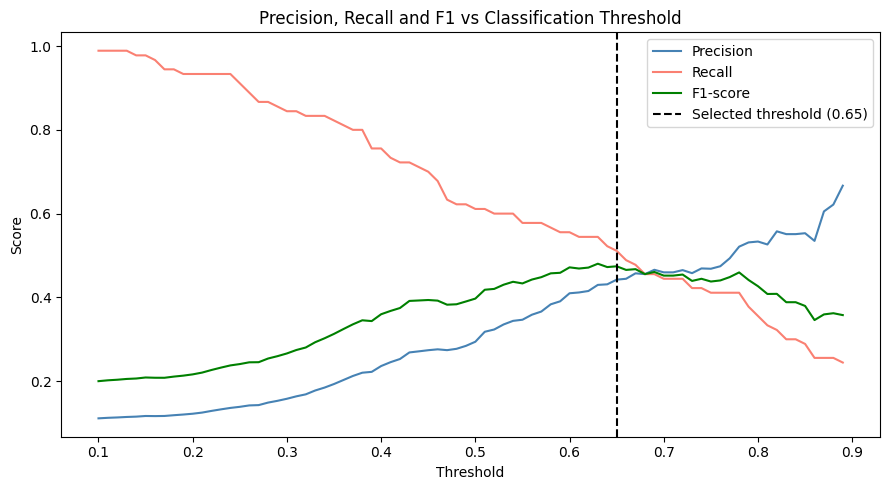

In [30]:
thresholds_range = np.arange(0.1, 0.9, 0.01)
precisions, recalls, f1s = [], [], []

for t in thresholds_range:
    y_t = (y_pred_proba > t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    precisions.append(precision_score(y_val, y_t, zero_division=0))
    recalls.append(recall_score(y_val, y_t, zero_division=0))
    f1s.append(f1_score(y_val, y_t, zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(thresholds_range, precisions, label='Precision', color='steelblue')
plt.plot(thresholds_range, recalls, label='Recall', color='salmon')
plt.plot(thresholds_range, f1s, label='F1-score', color='green')
plt.axvline(x=0.65, color='black', linestyle='--', label='Selected threshold (0.65)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Classification Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# Precision, Recall and F1 vs Classification Threshold
This plot shows how Precision, Recall and F1-score change as the classification threshold is varied from 0.1 to 0.9. It directly justifies the choice of threshold = 0.65.

The crossover point where Precision and Recall intersect occurs at approximately 
threshold 0.65, further confirming this as the natural operating point for this 
model.

### Potential Improvements

There are several potential avenues that could improve model performance:

- **Partial SMOTE balancing**: Rather than fully balancing the training set to a 50:50 ratio, using `sampling_strategy=0.5` would create an approximate 67:33 distribution. This would reduce the distribution shift introduced by full balancing while still encouraging the model to learn minority class patterns. A less aggressive resampling strategy may also reduce false positives in production.

- **Tuning the regularisation strength**: The default value of `C=1` was used for Logistic Regression. A smaller value of C (stronger regularisation) may reduce variance and improve generalisation, whereas a larger value could increase Recall by allowing the model to fit the minority class more closely. This hyperparameter should be tuned strictly on the validation set to preserve evaluation integrity.

- **Threshold optimisation using validation data**: Although a threshold of 0.65 was selected, this could be optimised more systematically using the Precision–Recall curve or by maximising F1-score on the validation set. Since the business objective prioritises minority class detection, threshold selection should explicitly reflect that cost structure.

- **Feature engineering**: Interaction terms between macroeconomic variables (such as `euribor3m` or `emp.var.rate`) and campaign-related variables may allow the model to capture conditional effects that a purely linear decision boundary cannot represent without explicit interaction terms.

- **Class weights instead of SMOTE**: Using `class_weight='balanced'` in Logistic Regression would adjust the loss function without generating synthetic data. This approach may reduce calibration issues introduced by resampling and could provide a more stable alternative to SMOTE while still addressing class imbalance.

These improvements are noted but not implemented, as the emphasis of this assignment is on pipeline discipline, correct ordering and leakage prevention rather than performance optimisation. The achieved AUC of 0.79 and Average Precision of 0.46 indicate that the model is learning meaningful patterns beyond the Zero Rule baseline while maintaining methodological coherence.